In [1]:
# 📊 Day 09 Practice Notebook: Variance, Covariance, IQR, Z-Score
# Author: AI Learning Journey
# Goal: Deep understanding with theory + hands-on practice

# ============================================================
# 🔹 SECTION 1: IMPORT LIBRARIES
# ============================================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# ============================================================
# 🔹 SECTION 2: VARIANCE (THEORY + PRACTICE)
# ============================================================

# THEORY:
# Variance measures how far data points are from the mean.
# Formula: Var(X) = (1/N) * Σ(x_i - μ)^2
#
# Intuition:
# - Low variance → values are close to mean
# - High variance → values are spread out

In [5]:
# Example dataset
low_variance = [10, 11, 10, 12, 11]
high_variance = [2, 20, 5, 30, 1]

print("Low variance:", np.var(low_variance))
print("High variance:", np.var(high_variance))

Low variance: 0.56
High variance: 131.44


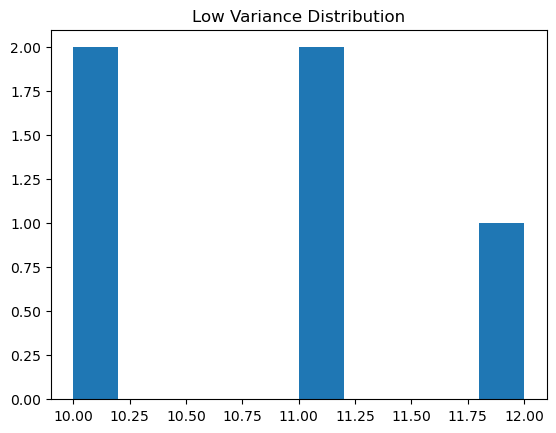

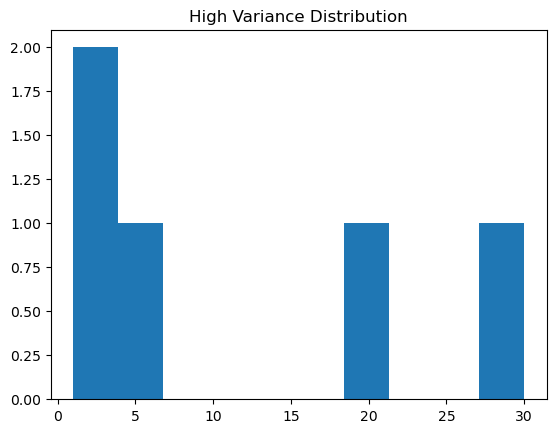

In [6]:
# Visualization
plt.hist(low_variance)
plt.title("Low Variance Distribution")
plt.show()

plt.hist(high_variance)
plt.title("High Variance Distribution")
plt.show()

In [7]:
# ============================================================
# 🔹 SECTION 3: COVARIANCE (THEORY + PRACTICE)
# ============================================================

# THEORY:
# Covariance measures how two variables move together.
# Formula: Cov(X,Y) = (1/N) * Σ(x_i - μ_x)(y_i - μ_y)
#
# Interpretation:
# +ve → move together
# -ve → opposite direction
# 0 → no relationship

In [8]:
# Example data
x = np.array([1, 2, 3, 4, 5])
y_positive = np.array([2, 4, 6, 8, 10])
y_negative = np.array([10, 8, 6, 4, 2])

In [9]:
print("Positive Covariance: ", np.cov(x, y_positive))
print("Negative Covariance: ", np.cov(x, y_negative))

Positive Covariance:  [[ 2.5  5. ]
 [ 5.  10. ]]
Negative Covariance:  [[ 2.5 -5. ]
 [-5.  10. ]]


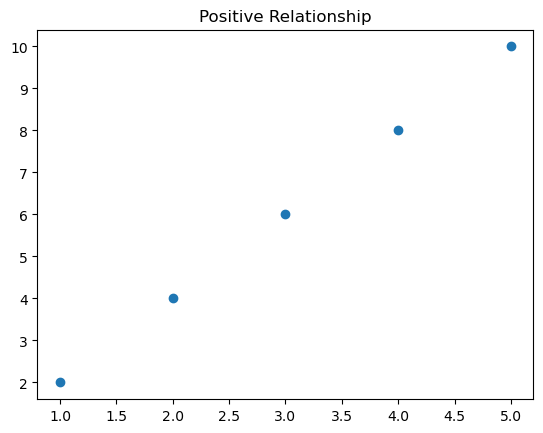

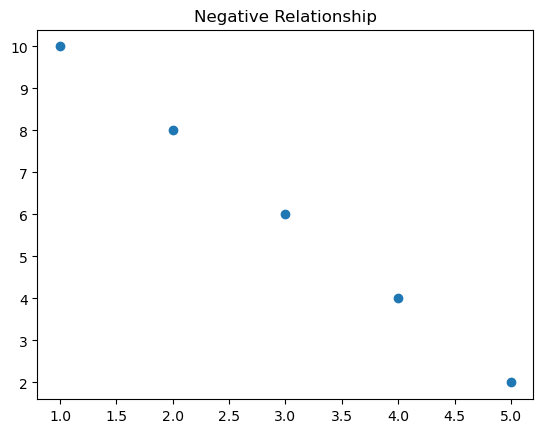

In [10]:
# Scatter plots
plt.scatter(x, y_positive)
plt.title("Positive Relationship")
plt.show()

plt.scatter(x, y_negative)
plt.title("Negative Relationship")
plt.show()


In [11]:
# ============================================================
# 🔹 SECTION 4: IQR (INTERQUARTILE RANGE)
# ============================================================

# THEORY:
# IQR = Q3 - Q1
# It represents middle 50% of data
#
# Outlier Rule:
# Lower Bound = Q1 - 1.5 * IQR
# Upper Bound = Q3 + 1.5 * IQR


In [12]:
# Example data with outliers
data = [10, 12, 14, 15, 18, 19, 100]
Q1 = np.percentile(data, 25)
Q3 = np.percentile(data, 75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5*IQR
upper_bound = Q3 + 1.5*IQR


print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)


Q1: 13.0
Q3: 18.5
IQR: 5.5
Lower Bound: 4.75
Upper Bound: 26.75


In [13]:
#detect outliers
outliers = [x for x in data if x < lower_bound or x > upper_bound]

Outliers: [100]


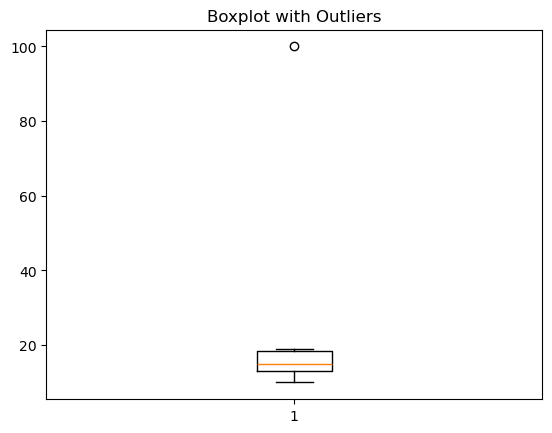

In [14]:
print("Outliers:", outliers)

# Boxplot
plt.boxplot(data)
plt.title("Boxplot with Outliers")
plt.show()

In [15]:
# ============================================================
# 🔹 SECTION 5: Z-SCORE (STANDARDIZATION)
# ============================================================

In [16]:
# THEORY:
# Z = (X - μ) / σ
#
# Interpretation:
# Z = 0 → mean
# Z > 2 → far
# Z > 3 → likely outlier


In [17]:
# Example data
values = np.array([10, 12, 14, 15, 18, 19, 100])

In [21]:
mean = np.mean(values)
std = np.std(values)

z_scores = (values - mean)/std

In [22]:
print("Mean:", mean)
print("Std Dev:", std)
print("Z-Scores:", z_scores)

Mean: 26.857142857142858
Std Dev: 30.00204074691573
Z-Scores: [-0.56186654 -0.49520441 -0.42854228 -0.39521121 -0.29521801 -0.26188695
  2.4379294 ]


In [26]:
# Detect outliers using Z-score
z_outliers = values[np.abs(z_scores) > 3]
print("Z-score Outliers:", z_outliers)

Z-score Outliers: []


In [27]:
# ============================================================
# 🔹 SECTION 6: MINI PROJECT (INDUSTRY STYLE)
# ============================================================

# Scenario: Detect abnormal transactions

np.random.seed(42)

# Generate normal transactions
transactions = np.random.normal(loc=500, scale=50, size=100)

# Add anomalies
transactions = np.append(transactions, [1200, 1500, 50])



In [32]:
# Convert to DataFrame
df = pd.DataFrame({"amount": transactions})
print(df)

          amount
0     524.835708
1     493.086785
2     532.384427
3     576.151493
4     488.292331
..           ...
98    500.255673
99    488.270643
100  1200.000000
101  1500.000000
102    50.000000

[103 rows x 1 columns]


In [34]:
mean = df["amount"].mean()
std = df["amount"].std()

df["z_score"]=(df["amount"]-mean)/std

In [36]:
z_outliers = df[np.abs(df['z_score']) > 3]

Z-score Outliers:
      amount   z_score
100  1200.0  5.084727
101  1500.0  7.286209
102    50.0 -3.354286
IQR Outliers:
           amount   z_score
74    369.012745 -1.013284
100  1200.000000  5.084727
101  1500.000000  7.286209
102    50.000000 -3.354286


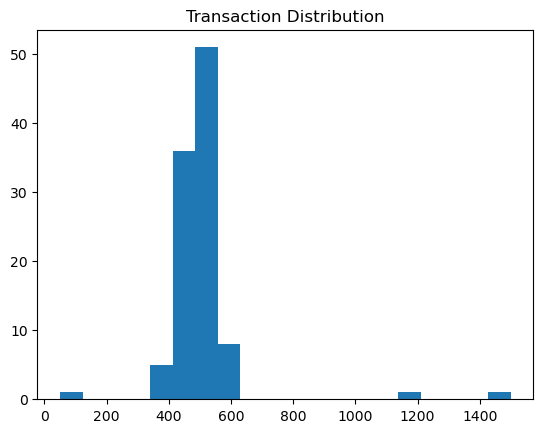

In [37]:
# --- IQR method ---
Q1 = df["amount"].quantile(0.25)
Q3 = df["amount"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

iqr_outliers = df[(df['amount'] < lower) | (df['amount'] > upper)]
print("Z-score Outliers:\n", z_outliers)
print("IQR Outliers:\n", iqr_outliers)

# Visualization
plt.hist(df['amount'], bins=20)
plt.title("Transaction Distribution")
plt.show()


In [38]:
# ============================================================
# 🔹 FINAL INSIGHTS
# ============================================================

# 1. Variance → spread of data
# 2. Covariance → relationship between variables
# 3. IQR → robust outlier detection
# 4. Z-score → scaling + outlier detection
#
# Interview Tip:
# - Use IQR for skewed data
# - Use Z-score for normal distributions
#
# ============================================================
# END OF NOTEBOOK
# ============================================================
